# 재정대응지수 구축 및 재정반응성 기초분석

- 작성자: 이정연
- 관련 이슈: #62
- 분석 단위: 17개 시도 × 2016~2024년
- 범위: 전체 계획예산 기반 잠정 지수 구축

## 분석 배경과 방법

이전 출산동향과 다음 해 예산편성의 시차적 관계를 분석할 기초 패널을 만든다.

### 주요 가정

- 예산은 2020년 가격으로 실질화한다.
- 실질예산을 자연로그로 변환한 뒤 전체 지역×연도 기준으로 표준화한다.
- 출산동향은 예산편성 이전 값만 사용한다.
- 원자료 누락 관측치는 보정하지 않고 표시한다.

### 1. 분석 환경 설정

In [1]:
from pathlib import Path
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
korean_font_candidates = ("AppleGothic", "Malgun Gothic", "NanumGothic")
KOREAN_FONT = next(
    (font for font in korean_font_candidates if font in installed_fonts),
    "sans-serif",
)
plt.rcParams.update({"font.family": KOREAN_FONT, "axes.unicode_minus": False})

np.random.seed(42)

current_dir = Path.cwd().resolve()
PROJECT_ROOT = next(
    path for path in (current_dir, *current_dir.parents) if (path / "pyproject.toml").exists()
)

PANEL_PATH = (
    PROJECT_ROOT / "data/processed/analysis/2016-2024_시도별_계획예산_합계출산율_기초패널.csv"
)
CPI_PATH = PROJECT_ROOT / "data/lookup/연도별_소비자물가지수.csv"
REGION_MAP_PATH = PROJECT_ROOT / "data/lookup/시도_지역코드_매핑.csv"
POPULATION_PATH = next(
    path
    for path in (PROJECT_ROOT / "data/raw").rglob("*.xlsx")
    if "청년고용률 원자료" in unicodedata.normalize("NFC", str(path))
    and "1세별_주민등록인구" in unicodedata.normalize("NFC", path.name)
)

START_YEAR = 2016
END_YEAR = 2024
EXPECTED_REGIONS = 17
CPI_BASE_VALUE = 100.0

print(f"프로젝트 경로: {PROJECT_ROOT}")
print(f"그래프 한글 글꼴: {KOREAN_FONT}")

프로젝트 경로: /Users/leejungyeon/Workspace/projects/한국재정정보원/yumocha
그래프 한글 글꼴: AppleGothic


## 데이터

### 2. 입력 데이터 불러오기 및 검증

In [2]:
panel_raw = pd.read_csv(PANEL_PATH)
cpi_raw = pd.read_csv(CPI_PATH)
region_map = pd.read_csv(REGION_MAP_PATH)
population_raw = pd.read_excel(POPULATION_PATH)

display(panel_raw.head(3))
display(cpi_raw[["연도", "소비자물가지수", "기준연도", "출처기관", "조회일"]])
print("기초패널 shape:", panel_raw.shape)
print("소비자물가지수 shape:", cpi_raw.shape)
print("주민등록인구 shape:", population_raw.shape)

,지역,연도,당해계획예산_백만원,세부사업수,예산금액_존재_사업수,예산결측_사업수,음수예산_사업수,합계출산율,예산_QA_그룹수,예산_QA_일치건수,예산_QA_불일치건수,예산_QA_판정불가건수,예산_QA_허용초과건수,예산_QA_최대절대오차율,원자료_누락주의
0,강원,2016,"966,330.0000",251,250,1,0,1.2370,6,3,3,0,0,3.0400,NaN
1,강원,2017,"1,189,656.0000",276,276,0,0,1.1230,6,0,0,6,0,NaN,NaN
2,강원,2018,"1,070,709.0000",77,77,0,0,1.0670,3,0,0,3,0,NaN,원자료에 자체사업 상세가 없어 세부사업 합계가 과소대표될 수 있음


,연도,소비자물가지수,기준연도,출처기관,조회일
0,2016,95.7180,2020=100,통계청,2026-07-27
1,2017,97.4920,2020=100,통계청,2026-07-27
2,2018,99.1580,2020=100,통계청,2026-07-27
3,2019,99.4670,2020=100,통계청,2026-07-27
4,2020,100.0000,2020=100,통계청,2026-07-27
5,2021,102.5900,2020=100,통계청,2026-07-27
6,2022,108.0600,2020=100,통계청,2026-07-27
7,2023,111.6200,2020=100,통계청,2026-07-27
8,2024,114.2400,2020=100,통계청,2026-07-27


기초패널 shape: (153, 15)
소비자물가지수 shape: (9, 11)
주민등록인구 shape: (3672, 13)


In [3]:
PANEL_KEY = ["지역", "연도"]
required_panel_columns = {
    "지역",
    "연도",
    "당해계획예산_백만원",
    "합계출산율",
    "원자료_누락주의",
}
required_cpi_columns = {"연도", "소비자물가지수", "기준연도"}

assert required_panel_columns.issubset(panel_raw.columns)
assert required_cpi_columns.issubset(cpi_raw.columns)
assert not panel_raw.duplicated(PANEL_KEY).any()
assert not cpi_raw.duplicated(["연도"]).any()
assert panel_raw["연도"].between(START_YEAR, END_YEAR).all()
assert panel_raw["지역"].nunique() == EXPECTED_REGIONS
assert len(panel_raw) == EXPECTED_REGIONS * (END_YEAR - START_YEAR + 1)
assert panel_raw.groupby("연도")["지역"].nunique().eq(EXPECTED_REGIONS).all()
assert panel_raw["당해계획예산_백만원"].notna().all()
assert panel_raw["합계출산율"].between(0, 5).all()
assert cpi_raw["연도"].tolist() == list(range(START_YEAR, END_YEAR + 1))
assert cpi_raw["소비자물가지수"].gt(0).all()
assert cpi_raw["기준연도"].nunique() == 1

input_qa = pd.Series(
    {
        "관측치": len(panel_raw),
        "지역수": panel_raw["지역"].nunique(),
        "연도수": panel_raw["연도"].nunique(),
        "키중복": int(panel_raw.duplicated(PANEL_KEY).sum()),
        "예산결측": int(panel_raw["당해계획예산_백만원"].isna().sum()),
        "출산율결측": int(panel_raw["합계출산율"].isna().sum()),
        "원자료누락주의": int(panel_raw["원자료_누락주의"].notna().sum()),
    },
    name="값",
)
display(input_qa.to_frame())

,값
관측치,153
지역수,17
연도수,9
키중복,0
예산결측,0
출산율결측,0
원자료누락주의,2


### 3. 20~39세 인구 패널 생성

In [4]:
population = population_raw.rename(
    columns={
        "행정구역(시군구)별": "지역명_전체",
        "연령별": "연령",
    }
).copy()
population["연령_숫자"] = pd.to_numeric(
    population["연령"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce",
)

year_columns = {
    column: int(str(column).split()[0])
    for column in population.columns
    if str(column).split()[0].isdigit() and START_YEAR <= int(str(column).split()[0]) <= END_YEAR
}

population_20_39 = population.loc[
    population["연령_숫자"].between(20, 39)
    & population["항목"].eq("총인구수[명]")
    & population["지역명_전체"].ne("전국"),
    ["지역명_전체", "연령_숫자", *year_columns],
].copy()

assert population_20_39["지역명_전체"].nunique() == EXPECTED_REGIONS
assert population_20_39.groupby("지역명_전체")["연령_숫자"].nunique().eq(20).all()

population_panel = (
    population_20_39.groupby("지역명_전체", as_index=False)[list(year_columns)]
    .sum()
    .rename(columns=year_columns)
    .melt(
        id_vars="지역명_전체",
        var_name="연도",
        value_name="20_39세_인구_명",
    )
    .merge(
        region_map[["지역", "지역명_전체"]],
        on="지역명_전체",
        how="left",
        validate="many_to_one",
    )[["지역", "연도", "20_39세_인구_명"]]
    .sort_values(PANEL_KEY)
    .reset_index(drop=True)
)

assert len(population_panel) == EXPECTED_REGIONS * (END_YEAR - START_YEAR + 1)
assert not population_panel.duplicated(PANEL_KEY).any()
assert population_panel["지역"].notna().all()
assert population_panel["20_39세_인구_명"].gt(0).all()

display(population_panel.head())
display(
    population_panel.groupby("연도", as_index=False)["20_39세_인구_명"]
    .sum()
    .rename(columns={"20_39세_인구_명": "전국_20_39세_인구_명"})
)

,지역,연도,20_39세_인구_명
0,강원,2016,370276
1,강원,2017,366102
2,강원,2018,358469
3,강원,2019,351771
4,강원,2020,346364


,연도,전국_20_39세_인구_명
0,2016,14292568
1,2017,14179616
2,2018,14094116
3,2019,13881380
4,2020,13679270
5,2021,13379358
6,2022,13032692
7,2023,12773034
8,2024,12580219


### 4. 예산 실질화 및 잠정 지수 산출

실질예산을 계산한 뒤 자연로그 변환과 전체 분석 대상 기준 표준화를 적용한다.

In [5]:
fiscal_panel = (
    panel_raw.merge(
        cpi_raw[["연도", "소비자물가지수", "기준연도"]],
        on="연도",
        how="left",
        validate="many_to_one",
    )
    .merge(
        population_panel,
        on=PANEL_KEY,
        how="left",
        validate="one_to_one",
    )
    .sort_values(PANEL_KEY)
    .reset_index(drop=True)
)

assert fiscal_panel["소비자물가지수"].notna().all()
assert fiscal_panel["20_39세_인구_명"].notna().all()

fiscal_panel["실질계획예산_2020년가격_백만원"] = (
    fiscal_panel["당해계획예산_백만원"] * CPI_BASE_VALUE / fiscal_panel["소비자물가지수"]
)
fiscal_panel["log1p_실질계획예산"] = np.log1p(fiscal_panel["실질계획예산_2020년가격_백만원"])
fiscal_panel["20_39세_1인당_실질예산_원"] = (
    fiscal_panel["실질계획예산_2020년가격_백만원"] * 1_000_000 / fiscal_panel["20_39세_인구_명"]
)
fiscal_panel["log1p_20_39세_1인당_실질예산"] = np.log1p(fiscal_panel["20_39세_1인당_실질예산_원"])

pooled_mean = fiscal_panel["log1p_실질계획예산"].mean()
pooled_std = fiscal_panel["log1p_실질계획예산"].std(ddof=0)
assert pooled_std > 0

fiscal_panel["총액기준_재정대응지수_z"] = (
    fiscal_panel["log1p_실질계획예산"] - pooled_mean
) / pooled_std

per_capita_mean = fiscal_panel["log1p_20_39세_1인당_실질예산"].mean()
per_capita_std = fiscal_panel["log1p_20_39세_1인당_실질예산"].std(ddof=0)
assert per_capita_std > 0
fiscal_panel["재정대응지수_z"] = (
    fiscal_panel["log1p_20_39세_1인당_실질예산"] - per_capita_mean
) / per_capita_std
fiscal_panel["재정대응점수_0_100"] = (
    100
    * (fiscal_panel["재정대응지수_z"] - fiscal_panel["재정대응지수_z"].min())
    / (fiscal_panel["재정대응지수_z"].max() - fiscal_panel["재정대응지수_z"].min())
)

display(
    fiscal_panel[
        PANEL_KEY
        + [
            "당해계획예산_백만원",
            "소비자물가지수",
            "실질계획예산_2020년가격_백만원",
            "20_39세_인구_명",
            "20_39세_1인당_실질예산_원",
            "총액기준_재정대응지수_z",
            "재정대응지수_z",
            "재정대응점수_0_100",
        ]
    ].head(10)
)

,지역,연도,당해계획예산_백만원,소비자물가지수,실질계획예산_2020년가격_백만원,20_39세_인구_명,20_39세_1인당_실질예산_원,총액기준_재정대응지수_z,재정대응지수_z,재정대응점수_0_100
0,강원,2016,"966,330.0000",95.7180,"1,009,559.3305",370276,"2,726,504.9059",-0.5624,-0.3476,52.0760
1,강원,2017,"1,189,656.0000",97.4920,"1,220,260.1239",366102,"3,333,115.1534",-0.3535,0.0529,58.1904
2,강원,2018,"1,070,709.0000",99.1580,"1,079,800.9238",358469,"3,012,257.4721",-0.4882,-0.1489,55.1096
3,강원,2019,"1,610,182.0000",99.4670,"1,618,810.2587",351771,"4,601,886.6213",-0.0420,0.6959,68.0081
4,강원,2020,"1,479,594.0000",100.0000,"1,479,594.0000",346364,"4,271,789.2160",-0.1411,0.5475,65.7425
5,강원,2021,"1,968,341.0000",102.5900,"1,918,648.0164",338241,"5,672,428.8787",0.1452,1.1129,74.3739
6,강원,2022,"1,320,745.8000",108.0600,"1,222,233.7590",330559,"3,697,475.3645",-0.3517,0.2597,61.3480
7,강원,2023,"2,579,093.0000",111.6200,"2,310,601.1467",322204,"7,171,236.6909",0.3501,1.5803,81.5102
8,강원,2024,"2,540,007.0000",114.2400,"2,223,395.4832",314734,"7,064,363.8221",0.3077,1.5504,81.0532
9,경기,2016,"4,814,583.0000",95.7180,"5,029,966.1506",3643196,"1,380,646.5945",1.2073,-1.7042,31.3647


In [6]:
by_region = fiscal_panel.groupby("지역", sort=False)

fiscal_panel["실질예산_전년증감액_백만원"] = by_region["실질계획예산_2020년가격_백만원"].diff()
fiscal_panel["실질예산_전년증감률"] = by_region["실질계획예산_2020년가격_백만원"].pct_change(
    fill_method=None
)
fiscal_panel["log실질예산_전년변화"] = by_region["log1p_실질계획예산"].diff()
fiscal_panel["log1인당실질예산_전년변화"] = by_region["log1p_20_39세_1인당_실질예산"].diff()

fiscal_panel["전년도_합계출산율"] = by_region["합계출산율"].shift(1)
fiscal_panel["전전년도_합계출산율"] = by_region["합계출산율"].shift(2)
fiscal_panel["직전1년_출산율하락도"] = (
    fiscal_panel["전전년도_합계출산율"] - fiscal_panel["전년도_합계출산율"]
)

assert np.isfinite(
    fiscal_panel[
        [
            "실질계획예산_2020년가격_백만원",
            "20_39세_1인당_실질예산_원",
            "총액기준_재정대응지수_z",
            "재정대응지수_z",
        ]
    ].to_numpy()
).all()
assert np.isclose(fiscal_panel["재정대응지수_z"].mean(), 0.0, atol=1e-12)
assert np.isclose(fiscal_panel["재정대응지수_z"].std(ddof=0), 1.0, atol=1e-12)
assert fiscal_panel["실질예산_전년증감액_백만원"].isna().sum() == EXPECTED_REGIONS
assert fiscal_panel["직전1년_출산율하락도"].isna().sum() == EXPECTED_REGIONS * 2

feature_qa = pd.Series(
    {
        "지수평균": fiscal_panel["재정대응지수_z"].mean(),
        "지수표준편차_ddof0": fiscal_panel["재정대응지수_z"].std(ddof=0),
        "증감률무한값": np.isinf(fiscal_panel["실질예산_전년증감률"]).sum(),
        "출산율하락도_가용관측": fiscal_panel["직전1년_출산율하락도"].notna().sum(),
    },
    name="값",
)
display(feature_qa.to_frame())

,값
지수평균,-0.0000
지수표준편차_ddof0,1.0000
증감률무한값,0.0000
출산율하락도_가용관측,119.0000


## 분석 결과

### 5. 분포 및 추세 확인

In [7]:
summary_columns = [
    "당해계획예산_백만원",
    "실질계획예산_2020년가격_백만원",
    "20_39세_인구_명",
    "20_39세_1인당_실질예산_원",
    "log1p_실질계획예산",
    "총액기준_재정대응지수_z",
    "재정대응지수_z",
    "실질예산_전년증감률",
    "합계출산율",
    "직전1년_출산율하락도",
]
display(fiscal_panel[summary_columns].describe().T)

display(
    fiscal_panel.nlargest(10, "재정대응지수_z")[
        PANEL_KEY
        + [
            "20_39세_인구_명",
            "20_39세_1인당_실질예산_원",
            "재정대응지수_z",
            "원자료_누락주의",
        ]
    ]
)

,count,mean,std,min,25%,50%,75%,max
당해계획예산_백만원,153.0000,"2,502,081.1539","2,332,340.7072","89,445.0000","1,161,639.0000","1,757,736.5300","2,862,745.0000","13,821,287.0000"
실질계획예산_2020년가격_백만원,153.0000,"2,401,002.2527","2,184,702.4995","91,745.9894","1,097,019.9076","1,733,404.3754","2,846,270.6224","12,098,465.5112"
20_39세_인구_명,153.0000,"796,681.3922","941,360.0270","72,474.0000","358,469.0000","425,915.0000","773,496.0000","3,715,307.0000"
20_39세_1인당_실질예산_원,153.0000,"3,660,718.3917","1,854,668.1249","492,660.1930","2,413,368.3280","3,268,170.7049","4,601,886.6213","13,164,974.1167"
log1p_실질계획예산,153.0000,14.3353,0.9104,11.4268,13.9081,14.3656,14.8615,16.3086
총액기준_재정대응지수_z,153.0000,0.0000,1.0033,-3.2052,-0.4708,0.0333,0.5798,2.1745
재정대응지수_z,153.0000,-0.0000,1.0033,-3.7586,-0.5909,0.0136,0.6959,2.7914
실질예산_전년증감률,136.0000,0.1752,0.5909,-0.8220,-0.0301,0.0805,0.2229,3.1286
합계출산율,153.0000,0.9872,0.2210,0.5520,0.8270,0.9520,1.1220,1.8210
직전1년_출산율하락도,119.0000,0.0717,0.0449,-0.0850,0.0440,0.0720,0.1020,0.1950


,지역,연도,20_39세_인구_명,20_39세_1인당_실질예산_원,재정대응지수_z,원자료_누락주의
128,제주,2018,169441,"13,164,974.1167",2.7914,NaN
97,울산,2023,259431,"11,118,884.8210",2.4546,NaN
38,광주,2018,406163,"8,043,085.7769",1.8090,NaN
35,경북,2024,491584,"7,234,349.0962",1.5978,NaN
7,강원,2023,322204,"7,171,236.6909",1.5803,NaN
125,전북,2024,353910,"7,080,625.6865",1.5550,NaN
8,강원,2024,314734,"7,064,363.8221",1.5504,NaN
115,전남,2023,347654,"6,989,200.4934",1.5290,NaN
91,울산,2017,328031,"6,950,286.8053",1.5179,NaN
116,전남,2024,338373,"6,782,520.7205",1.4692,NaN


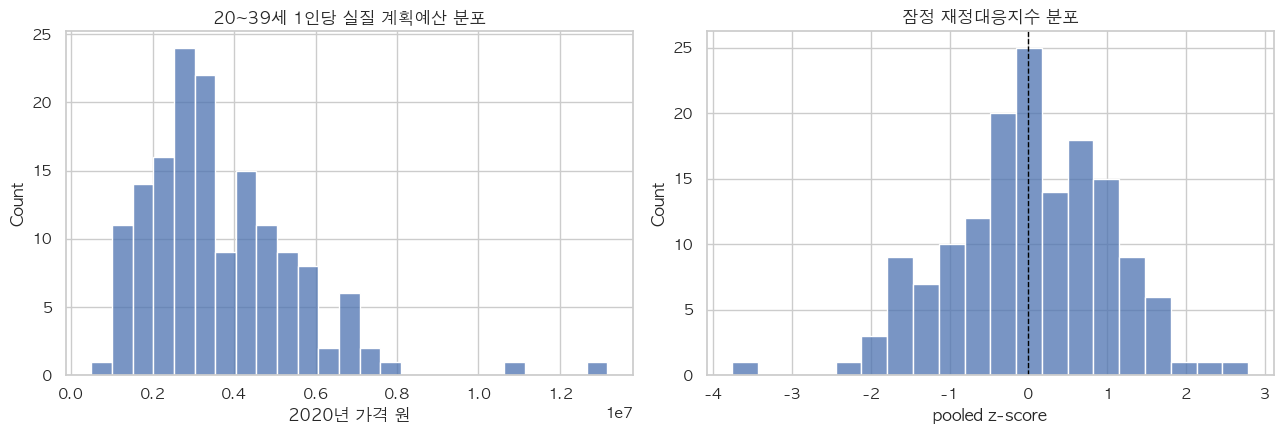

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(
    data=fiscal_panel,
    x="20_39세_1인당_실질예산_원",
    bins=25,
    ax=axes[0],
)
axes[0].set_title("20~39세 1인당 실질 계획예산 분포")
axes[0].set_xlabel("2020년 가격 원")

sns.histplot(data=fiscal_panel, x="재정대응지수_z", bins=20, ax=axes[1])
axes[1].axvline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_title("잠정 재정대응지수 분포")
axes[1].set_xlabel("pooled z-score")

plt.tight_layout()
plt.show()

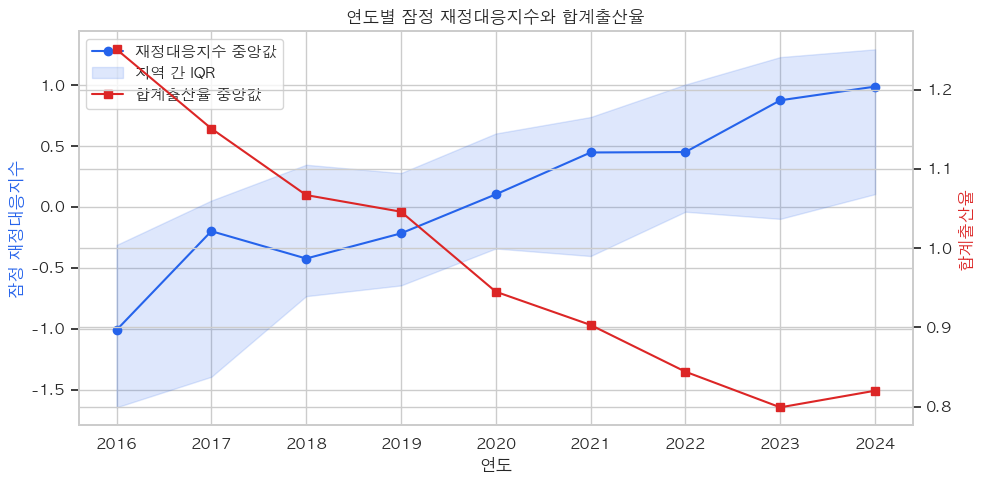

In [9]:
year_summary = fiscal_panel.groupby("연도", as_index=False).agg(
    재정대응지수_중앙값=("재정대응지수_z", "median"),
    재정대응지수_Q1=("재정대응지수_z", lambda values: values.quantile(0.25)),
    재정대응지수_Q3=("재정대응지수_z", lambda values: values.quantile(0.75)),
    합계출산율_중앙값=("합계출산율", "median"),
)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(
    year_summary["연도"],
    year_summary["재정대응지수_중앙값"],
    marker="o",
    color="#2563eb",
    label="재정대응지수 중앙값",
)
ax1.fill_between(
    year_summary["연도"],
    year_summary["재정대응지수_Q1"],
    year_summary["재정대응지수_Q3"],
    color="#2563eb",
    alpha=0.15,
    label="지역 간 IQR",
)
ax1.set_xlabel("연도")
ax1.set_ylabel("잠정 재정대응지수", color="#2563eb")

ax2 = ax1.twinx()
ax2.plot(
    year_summary["연도"],
    year_summary["합계출산율_중앙값"],
    marker="s",
    color="#dc2626",
    label="합계출산율 중앙값",
)
ax2.set_ylabel("합계출산율", color="#dc2626")

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="best")
ax1.set_title("연도별 잠정 재정대응지수와 합계출산율")
plt.tight_layout()
plt.show()

### 6. 1차 재정반응성 모형 분석 표본 구성

회귀 실행 전 시차 변수와 분석 가능 표본을 확인한다.

In [10]:
response_model_columns = [
    "지역",
    "연도",
    "재정대응지수_z",
    "총액기준_재정대응지수_z",
    "log1인당실질예산_전년변화",
    "직전1년_출산율하락도",
    "전년도_합계출산율",
    "원자료_누락주의",
]
response_model_sample = fiscal_panel.dropna(subset=["재정대응지수_z", "직전1년_출산율하락도"])[
    response_model_columns
].copy()

assert response_model_sample["연도"].min() == START_YEAR + 2
assert response_model_sample["지역"].nunique() == EXPECTED_REGIONS
assert not response_model_sample.duplicated(PANEL_KEY).any()

model_sample_qa = pd.Series(
    {
        "가용관측치": len(response_model_sample),
        "지역수": response_model_sample["지역"].nunique(),
        "최초연도": response_model_sample["연도"].min(),
        "최종연도": response_model_sample["연도"].max(),
        "원자료누락주의": response_model_sample["원자료_누락주의"].notna().sum(),
    },
    name="값",
)
display(model_sample_qa.to_frame())
display(response_model_sample.head())

,값
가용관측치,119
지역수,17
최초연도,2018
최종연도,2024
원자료누락주의,2


,지역,연도,재정대응지수_z,총액기준_재정대응지수_z,log1인당실질예산_전년변화,직전1년_출산율하락도,전년도_합계출산율,원자료_누락주의
2,강원,2018,-0.1489,-0.4882,-0.1012,0.1140,1.1230,원자료에 자체사업 상세가 없어 세부사업 합계가 과소대표될 수 있음
3,강원,2019,0.6959,-0.0420,0.4238,0.0560,1.0670,NaN
4,강원,2020,0.5475,-0.1411,-0.0744,-0.0150,1.0820,NaN
5,강원,2021,1.1129,0.1452,0.2836,0.0460,1.0360,NaN
6,강원,2022,0.2597,-0.3517,-0.4280,0.0570,0.9790,NaN


## 해석 및 다음 단계

- 주 지수는 20~39세 1인당 실질예산 기준 잠정 지수다.
- 총액 기준 지수는 비교용으로 함께 보존한다.
- 시차 분석 가용 표본은 119개다.
- 다음 단계에서 공통 함수·단위 테스트·기본모형을 작성한다.